In [1]:
import pandas as pd
import numpy as np
from utils.knn import KNN
from utils.metrics_evaluator import MetricsEvaluator
from utils.k_fold_cross_validation import KFoldCrossValidation
from utils.helpers import min_max_normalization, to_percent

In [2]:
# dm2 anu murni dm2 hngkl
# dm2-all anu boga panyakit lain diasupken, tuluy direname
df = pd.read_csv("dataset-dm2.csv")
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.0,70.0,154.0,DM2
1,77.0,P,160.0,90.0,71.0,DM2
2,38.0,P,90.0,70.0,154.0,DM2
3,41.0,P,NaN,NaN,NaN,DM2
4,42.0,P,NaN,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.0,84.0,118.0,NDM
802,23.0,Perempuan,121.0,79.0,109.0,NDM
803,29.0,Perempuan,118.0,74.0,96.0,NDM
804,22.0,Perempuan,119.0,78.0,95.0,NDM


In [3]:
missingSistolikCount = df['sistolik'].isna().sum()
print(missingSistolikCount)

24


In [4]:
# Filling missing 'sistolik' values with the mean
df['sistolik'] = df['sistolik'].fillna(df['sistolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.0,154.0,DM2
1,77.0,P,160.000000,90.0,71.0,DM2
2,38.0,P,90.000000,70.0,154.0,DM2
3,41.0,P,126.200767,NaN,NaN,DM2
4,42.0,P,126.200767,NaN,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.0,118.0,NDM
802,23.0,Perempuan,121.000000,79.0,109.0,NDM
803,29.0,Perempuan,118.000000,74.0,96.0,NDM
804,22.0,Perempuan,119.000000,78.0,95.0,NDM


In [5]:
missingDiastolikCount = df['diastolik'].isna().sum()
print(missingDiastolikCount)

24


In [6]:
# Mengisi nilai yang hilang pada kolom Diastolik dengan nilai rata-rata mean (nilai rata-rata)
df['diastolik'] = df['diastolik'].fillna(df['diastolik'].mean())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,NaN,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [7]:
missingGdsCount = df['gds'].isna().sum()
print(missingGdsCount)

36


In [8]:
# Mengisi nilai yang hilang pada kolom gds dengan nilai median (nilai tengah)
df['gds'] = df['gds'].fillna(df['gds'].median())
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [9]:
missingGenderCount = df['jenis_kelamin'].isna().sum()
print(missingGenderCount)

0


In [10]:
# Mengisi nilai yang hilang pada kolom jenis_kelamin dengan nilai modus (nilai yang sering mucul)
df['jenis_kelamin'] = df['jenis_kelamin'].fillna(df['jenis_kelamin'].mode()[0])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa
0,43.0,L,90.000000,70.000000,154.0,DM2
1,77.0,P,160.000000,90.000000,71.0,DM2
2,38.0,P,90.000000,70.000000,154.0,DM2
3,41.0,P,126.200767,80.202046,154.0,DM2
4,42.0,P,126.200767,80.202046,227.0,DM2
...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM


In [11]:
# Mapping Gender: P (Perempuan) to 1, L (Laki-laki) to 0
df['transformed_gender'] = df['jenis_kelamin'].map(lambda e: 1 if e == 'P' or e == 'Perempuan' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,DM2,0
1,77.0,P,160.000000,90.000000,71.0,DM2,1
2,38.0,P,90.000000,70.000000,154.0,DM2,1
3,41.0,P,126.200767,80.202046,154.0,DM2,1
4,42.0,P,126.200767,80.202046,227.0,DM2,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,NDM,1
802,23.0,Perempuan,121.000000,79.000000,109.0,NDM,1
803,29.0,Perempuan,118.000000,74.000000,96.0,NDM,1
804,22.0,Perempuan,119.000000,78.000000,95.0,NDM,1


In [12]:
df['diagnosa'] = df['diagnosa'].map(lambda e: 1 if e == 'DM2' else 0)
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender
0,43.0,L,90.000000,70.000000,154.0,1,0
1,77.0,P,160.000000,90.000000,71.0,1,1
2,38.0,P,90.000000,70.000000,154.0,1,1
3,41.0,P,126.200767,80.202046,154.0,1,1
4,42.0,P,126.200767,80.202046,227.0,1,1
...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1


In [13]:
# Normalisasi kolom sistolik
df['norm_sistolik'] = min_max_normalization(df['sistolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007
...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545


In [14]:
# Normalisasi kolom diastolik
df['norm_diastolik'] = min_max_normalization(df['diastolik'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202
...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000


In [15]:
# Normalisasi kolom Umur
df['norm_umur'] = min_max_normalization(df['umur'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733
...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384


In [16]:
# Normalisasi kolom gds (Gula Darah Sewaktu)
df['norm_gds'] = min_max_normalization(df['gds'])
df

,umur,jenis_kelamin,sistolik,diastolik,gds,diagnosa,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds
0,43.0,L,90.000000,70.000000,154.0,1,0,0.090909,0.19000,0.065250,0.157076
1,77.0,P,160.000000,90.000000,71.0,1,1,0.727273,0.39000,0.116844,0.027994
2,38.0,P,90.000000,70.000000,154.0,1,1,0.090909,0.19000,0.057663,0.157076
3,41.0,P,126.200767,80.202046,154.0,1,1,0.420007,0.29202,0.062215,0.157076
4,42.0,P,126.200767,80.202046,227.0,1,1,0.420007,0.29202,0.063733,0.270607
...,...,...,...,...,...,...,...,...,...,...,...
801,35.0,Perempuan,127.000000,84.000000,118.0,0,1,0.427273,0.33000,0.053111,0.101089
802,23.0,Perempuan,121.000000,79.000000,109.0,0,1,0.372727,0.28000,0.034901,0.087092
803,29.0,Perempuan,118.000000,74.000000,96.0,0,1,0.345455,0.23000,0.044006,0.066874
804,22.0,Perempuan,119.000000,78.000000,95.0,0,1,0.354545,0.27000,0.033384,0.065319


newDf ini adalah cerminan dari dataset mentah yang sudah ditambahkan kolom transformasi dan normalisasi

In [18]:
newDf = df[['umur', 'sistolik', 'diastolik', 'gds', 'transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'diagnosa']]
newDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,43.0,90.000000,70.000000,154.0,0,0.090909,0.19000,0.065250,0.157076,1
1,77.0,160.000000,90.000000,71.0,1,0.727273,0.39000,0.116844,0.027994,1
2,38.0,90.000000,70.000000,154.0,1,0.090909,0.19000,0.057663,0.157076,1
3,41.0,126.200767,80.202046,154.0,1,0.420007,0.29202,0.062215,0.157076,1
4,42.0,126.200767,80.202046,227.0,1,0.420007,0.29202,0.063733,0.270607,1
...,...,...,...,...,...,...,...,...,...,...
801,35.0,127.000000,84.000000,118.0,1,0.427273,0.33000,0.053111,0.101089,0
802,23.0,121.000000,79.000000,109.0,1,0.372727,0.28000,0.034901,0.087092,0
803,29.0,118.000000,74.000000,96.0,1,0.345455,0.23000,0.044006,0.066874,0
804,22.0,119.000000,78.000000,95.0,1,0.354545,0.27000,0.033384,0.065319,0


reorderDf adalah newDf yang diacak urutannya, perlu diingat ini belum diekspor menjadi csv, proses ekspor ke csv ada di cell di bawah ini

In [32]:
reorderDf = newDf.sample(frac=1).reset_index(drop=True)
reorderDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,58.0,110.0,80.0,233.0,1,0.272727,0.29,0.088012,0.279938,1
1,60.0,142.0,90.0,355.0,1,0.563636,0.39,0.091047,0.469673,1
2,57.0,120.0,80.0,227.0,1,0.363636,0.29,0.086495,0.270607,1
3,20.0,122.0,80.0,110.0,1,0.381818,0.29,0.030349,0.088647,0
4,72.0,121.0,80.0,189.0,0,0.372727,0.29,0.109256,0.211509,0
...,...,...,...,...,...,...,...,...,...,...
801,69.0,140.0,90.0,117.0,1,0.545455,0.39,0.104704,0.099533,1
802,24.0,122.0,81.0,107.0,1,0.381818,0.30,0.036419,0.083981,0
803,18.0,116.0,72.0,103.0,1,0.327273,0.21,0.027314,0.077760,0
804,63.0,125.0,86.0,125.0,1,0.409091,0.35,0.095599,0.111975,0


Nahh di sini baru si reorderDf ini diekspor jadi csv yang siap disantap

In [33]:
reorderDf.to_csv("dataset_preprocessed.csv", index=False)

# Evaluasi Dataset
Mulai dari membaca csv yang sudah diekspor

In [52]:
readyDf = pd.read_csv("dataset_preprocessed.csv")
readyDf

,umur,sistolik,diastolik,gds,transformed_gender,norm_sistolik,norm_diastolik,norm_umur,norm_gds,diagnosa
0,58.0,110.0,80.0,233.0,1,0.272727,0.29,0.088012,0.279938,1
1,60.0,142.0,90.0,355.0,1,0.563636,0.39,0.091047,0.469673,1
2,57.0,120.0,80.0,227.0,1,0.363636,0.29,0.086495,0.270607,1
3,20.0,122.0,80.0,110.0,1,0.381818,0.29,0.030349,0.088647,0
4,72.0,121.0,80.0,189.0,0,0.372727,0.29,0.109256,0.211509,0
...,...,...,...,...,...,...,...,...,...,...
801,69.0,140.0,90.0,117.0,1,0.545455,0.39,0.104704,0.099533,1
802,24.0,122.0,81.0,107.0,1,0.381818,0.30,0.036419,0.083981,0
803,18.0,116.0,72.0,103.0,1,0.327273,0.21,0.027314,0.077760,0
804,63.0,125.0,86.0,125.0,1,0.409091,0.35,0.095599,0.111975,0


In [53]:
class DatasetEvaluator:
    def __init__(self, df: pd.DataFrame, training_size: float):
        self.df = df
        self.training_size = int(df.shape[0] * training_size)
    
    def split_datasets(self):
        # Memisahkan fitur (X) dan target (y)
        X = self.df[['norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds', 'transformed_gender']]
        y = self.df['diagnosa']

        # Membagi dataset menjadi data Latih (Train) dan data Uji (Test)
        self.X_train = X.iloc[:self.training_size]
        self.y_train = y.iloc[:self.training_size]
        self.X_test = X.iloc[self.training_size:]
        self.y_test = y.iloc[self.training_size:]

        print("Dimensi data latih - {},{}".format(self.X_train.shape, self.y_train.shape))
        print("Dimensi data validasi - {},{}".format(self.X_test.shape, self.y_test.shape))
        
    def evaluate_knn(self):
        # Iterate through different K values and distance metrics to evaluate performance
        for k_count in np.array([3, 5, 7, 9]):
            knn = KNN(k=k_count)
            knn.fit(self.X_train, self.y_train)

            predictions = knn.predict(self.X_test.values)
            y_pred = predictions['Euclidean']
            
            # for distance_type, y_pred in predictions.items(): -> uncomment this if want to use all distance types
            evaluator = MetricsEvaluator(y_pred, self.y_test.values)
            evaluator.plot_confusion_matrix(title=f"Confusion Matrix - Jarak Euclidean (K={k_count})")
            accuracy = evaluator.accuracy()
            precision = evaluator.precision()
            recall = evaluator.recall()
            f1_score = evaluator.f1_score()

            print(f"Results for Euclidean Distance (K={k_count})")
            print(f"Accuracy: {to_percent(accuracy)}, Precision: {to_percent(precision)}, Recall: {to_percent(recall)}, F1-Score: {to_percent(f1_score)}")
            print("-" * 80)

# Pembagian Data
Membagi dataset dengan komposisi train:test dengan beberapa skenario, di antaranya 80:20, 75:25, 90:10

# 80:20

Dimensi data latih - (644, 5),(644,)
Dimensi data validasi - (162, 5),(162,)
Results for Euclidean Distance (K=3)
Accuracy: 85.80%, Precision: 80.26%, Recall: 88.41%, F1-Score: 84.14%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 82.72%, Precision: 75.31%, Recall: 88.41%, F1-Score: 81.33%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 80.86%, Precision: 73.75%, Recall: 85.51%, F1-Score: 79.19%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 81.48%, Precision: 75.32%, Recall: 84.06%, F1-Score: 79.45%
--------------------------------------------------------------------------------


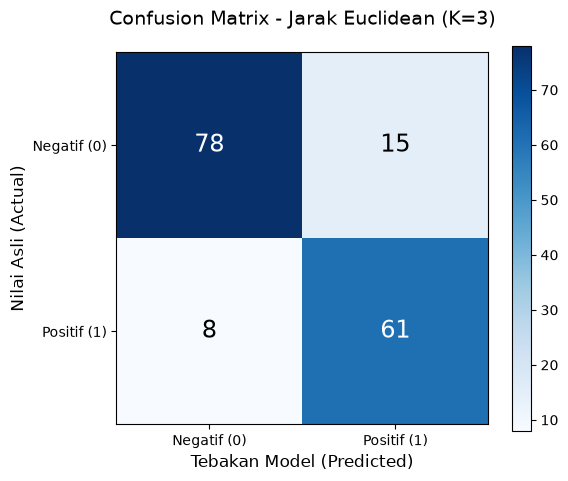

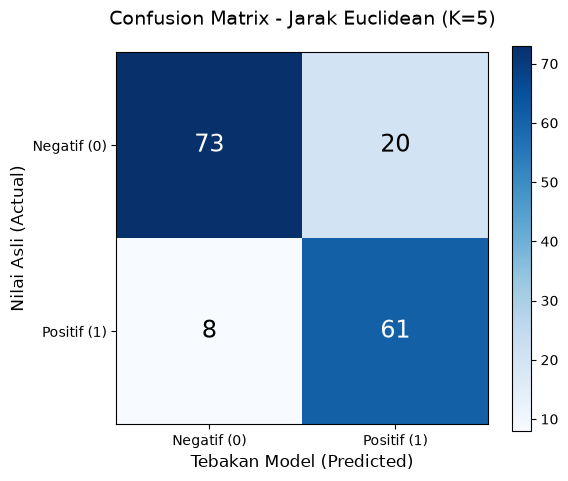

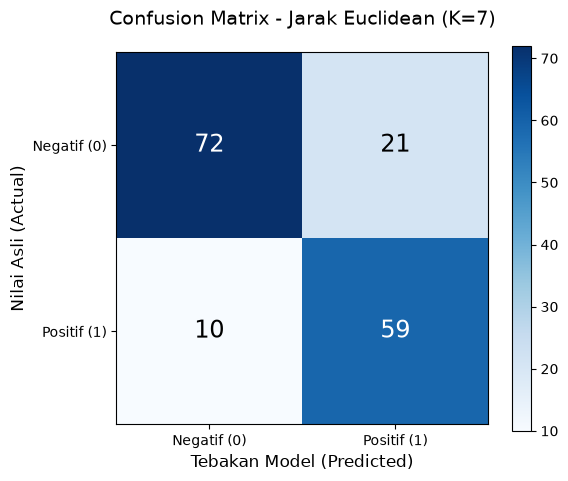

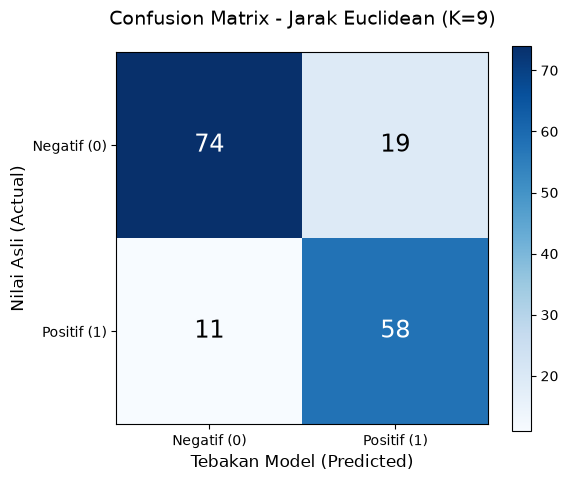

In [58]:
datasetEighty = DatasetEvaluator(readyDf, training_size=0.8)
datasetEighty.split_datasets()
datasetEighty.evaluate_knn()

# Pembagian Data
Membagi dataset menjadi data latih (80%) dan data uji (20%).

# 75:25

Dimensi data latih - (604, 5),(604,)
Dimensi data validasi - (202, 5),(202,)
Results for Euclidean Distance (K=3)
Accuracy: 84.65%, Precision: 82.35%, Recall: 81.40%, F1-Score: 81.87%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 79.70%, Precision: 74.19%, Recall: 80.23%, F1-Score: 77.09%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 79.70%, Precision: 75.28%, Recall: 77.91%, F1-Score: 76.57%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 80.20%, Precision: 75.00%, Recall: 80.23%, F1-Score: 77.53%
--------------------------------------------------------------------------------


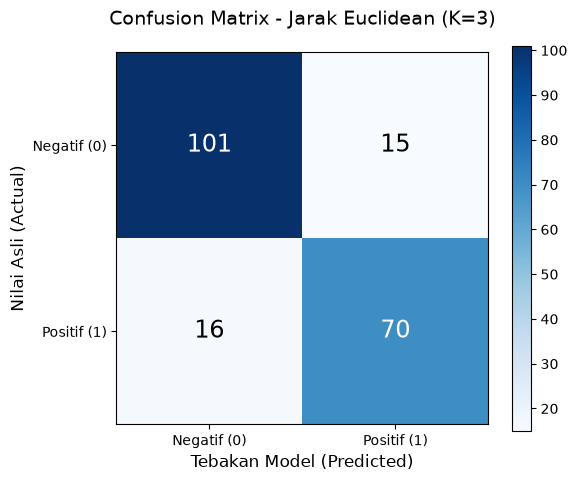

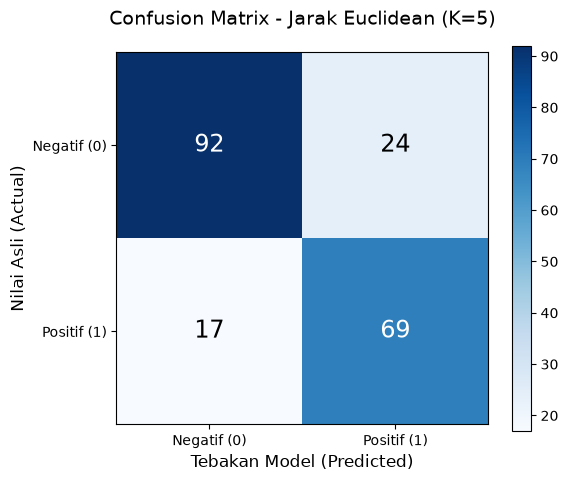

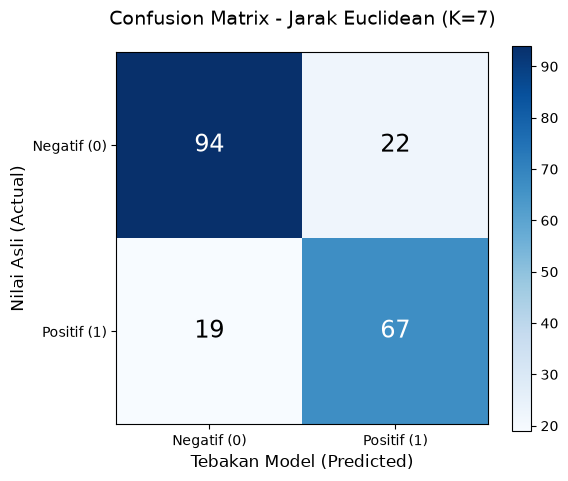

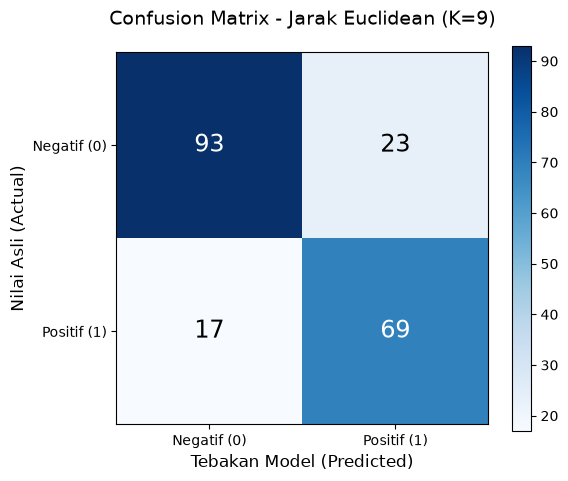

In [59]:
datasetSeventyFive = DatasetEvaluator(readyDf, training_size=0.75)
datasetSeventyFive.split_datasets()
datasetSeventyFive.evaluate_knn()

# 90:10

Dimensi data latih - (644, 5),(644,)
Dimensi data validasi - (162, 5),(162,)
Results for Euclidean Distance (K=3)
Accuracy: 85.80%, Precision: 80.26%, Recall: 88.41%, F1-Score: 84.14%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=5)
Accuracy: 82.72%, Precision: 75.31%, Recall: 88.41%, F1-Score: 81.33%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=7)
Accuracy: 80.86%, Precision: 73.75%, Recall: 85.51%, F1-Score: 79.19%
--------------------------------------------------------------------------------
Results for Euclidean Distance (K=9)
Accuracy: 81.48%, Precision: 75.32%, Recall: 84.06%, F1-Score: 79.45%
--------------------------------------------------------------------------------


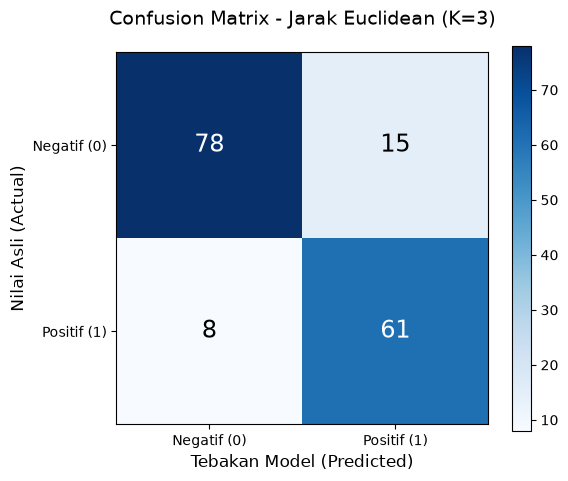

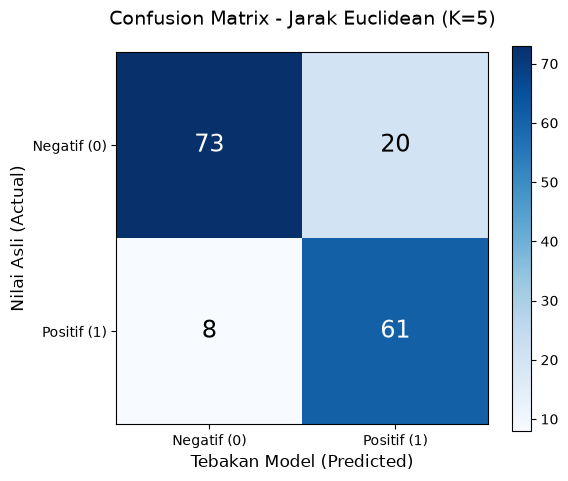

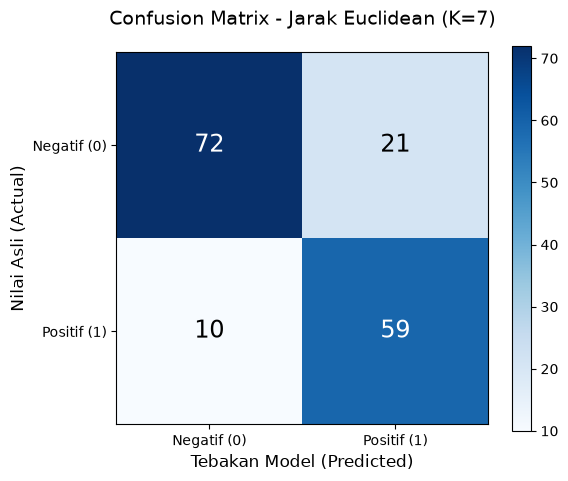

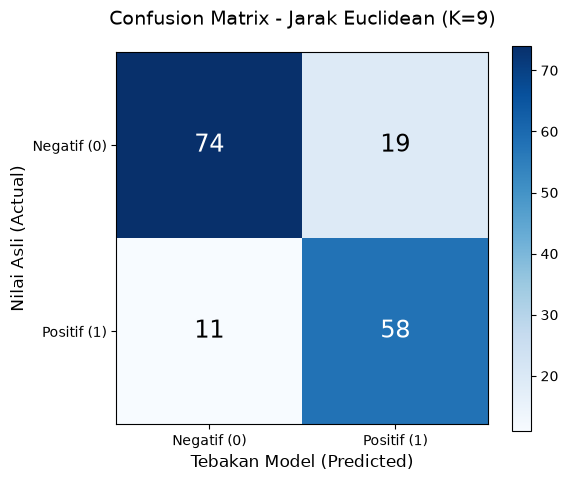

In [60]:
datasetNinety = DatasetEvaluator(readyDf, training_size=0.8)
datasetNinety.split_datasets()
datasetNinety.evaluate_knn()

# K-Fold Cross Validation => K = 5

In [43]:
K = 5

In [44]:
kFold = KFoldCrossValidation(readyDf, K)

In [48]:
# Siapkan list untuk nyimpen semua metrik
results_storage = []

for fold_index in range(K):
    [train_data, test_data] = kFold.get_train_test_split(fold_index)
    k_X_train = train_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
    k_y_train = train_data['diagnosa']
    k_X_test = test_data[['transformed_gender', 'norm_sistolik', 'norm_diastolik', 'norm_umur', 'norm_gds']]
    k_y_test = test_data['diagnosa']
    
    for k_count in np.array([3, 5, 7, 9]):
        print(f"Fold {fold_index + 1}/{K} - K={k_count}")
        knn = KNN(k=k_count)
        knn.fit(k_X_train, k_y_train)

        predictions = knn.predict(k_X_test.values)
        y_pred = predictions['Euclidean']
        
        # for distance_type, y_pred in predictions.items():
        evaluator = MetricsEvaluator(y_pred, k_y_test.values)
        
        results_storage.append({
            'Fold': fold_index + 1,
            'K': k_count,
            'Distance': 'Euclidean',
            'Accuracy': evaluator.accuracy(),
            'Precision': evaluator.precision(),
            'Recall': evaluator.recall(),
            'F1_Score': evaluator.f1_score()
        })

Fold 1/5 - K=3
Fold 1/5 - K=5
Fold 1/5 - K=7
Fold 1/5 - K=9
Fold 2/5 - K=3
Fold 2/5 - K=5
Fold 2/5 - K=7
Fold 2/5 - K=9
Fold 3/5 - K=3
Fold 3/5 - K=5
Fold 3/5 - K=7
Fold 3/5 - K=9
Fold 4/5 - K=3
Fold 4/5 - K=5
Fold 4/5 - K=7
Fold 4/5 - K=9
Fold 5/5 - K=3
Fold 5/5 - K=5
Fold 5/5 - K=7
Fold 5/5 - K=9


In [51]:
# Convert list of dicts tadi ke Pandas DataFrame
df_results = pd.DataFrame(results_storage)
df_results

# HITUNG RATA-RATA dari semua fold berdasarkan nilai K dan tipe jaraknya
df_avg = df_results.groupby(['K', 'Distance'])[['Accuracy', 'Precision', 'Recall', 'F1_Score']].mean().reset_index()
df_avg

,K,Distance,Accuracy,Precision,Recall,F1_Score
0,3,Euclidean,0.826355,0.817664,0.832063,0.823789
1,5,Euclidean,0.825090,0.813783,0.833837,0.822676
2,7,Euclidean,0.805230,0.798273,0.806560,0.801477
3,9,Euclidean,0.803995,0.795868,0.805385,0.800310
